# Scoring 01 — Cost-Sensitive Threshold Optimisation

First step of the Scoring stage. A probability model only becomes a lending decision
through a threshold. This notebook searches the threshold grid on the val-eval rows
(defined in Fitting 04 - the test split stays untouched) for two policies per model:
the F1-maximising threshold (best pure discrimination trade-off) and the expected-loss
minimising threshold under the three cost scenarios CFN/CFP = 5, 10, 20 used in the
thesis. The chosen thresholds are saved and applied unchanged to the test split in
Scoring 02.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import f1_score

In [2]:
# Paths, cost scenarios and the threshold grid. The cost ratios express how much more
# expensive a missed defaulter is than a wrongly rejected good borrower, derived from
# Dutch retail-lending margins and losses in the thesis methodology.
ARTIFACTS = Path("../artifacts")
COST_RATIOS = [5, 10, 20]
GRID = np.round(np.arange(0.01, 0.9901, 0.01), 2)

In [3]:
# Load the models and calibrators selected in the Fitting stage and the helper that
# turns raw model scores into calibrated probabilities (Platt calibrators are logistic
# regressions and use predict_proba; Beta and isotonic expose predict).
tuned = json.loads((ARTIFACTS / "tuned_params.json").read_text())
calibration = json.loads((ARTIFACTS / "calibration.json").read_text())
selected = tuned["selected"]
chosen_calibrator = calibration["selected_calibrator"]
models = {key: joblib.load(ARTIFACTS / "models" / f"{key}.joblib")
          for key in selected.values()}
calibrators = {key: joblib.load(ARTIFACTS / "calibrators" / f"{key}.joblib")
               for key in selected.values()}

def calibrated_probabilities(key, X):
    raw = models[key].predict_proba(X)[:, 1]
    calibrator = calibrators[key]
    if chosen_calibrator[key] == "platt":
        p = calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
    else:
        p = np.asarray(calibrator.predict(raw)).ravel()
    return np.clip(p, 0.0, 1.0)

print("models:", dict(selected), "  calibrators:", dict(chosen_calibrator))

models: {'logreg': 'logreg_C', 'rf': 'rf_C', 'xgb': 'xgb_C'}   calibrators: {'logreg_C': 'beta', 'rf_C': 'beta', 'xgb_C': 'isotonic'}


In [4]:
# Calibrated probabilities on the val-eval rows only. The val-fit rows trained the
# calibrators in Fitting 04, so using them here would bias the threshold choice; the
# saved index split guarantees the separation.
eval_idx = np.array(calibration["val_eval_idx"])
y_val = pd.read_parquet(ARTIFACTS / "val_configA.parquet")["target"].to_numpy()
y_eval = y_val[eval_idx]
probabilities = {}
for family, key in selected.items():
    cfg = key.split("_")[1]
    X_val = pd.read_parquet(ARTIFACTS / f"val_config{cfg}.parquet").drop(columns="target")
    probabilities[key] = calibrated_probabilities(key, X_val)[eval_idx]
print(f"val-eval rows: {len(y_eval):,}  default rate {y_eval.mean():.4%}")

val-eval rows: 17,927  default rate 6.6994%


In [5]:
# Decision metrics at a threshold t: a borrower is rejected when the predicted default
# probability is at least t. Expected loss counts each missed defaulter (false negative)
# at CFN times the cost of each wrongly rejected good borrower (false positive, cost 1),
# averaged over the portfolio - the thesis's cost-sensitive objective.
def confusion_at(y, p, t):
    predicted_default = p >= t
    tp = int(np.sum((y == 1) & predicted_default))
    fn = int(np.sum((y == 1) & ~predicted_default))
    fp = int(np.sum((y == 0) & predicted_default))
    tn = int(np.sum((y == 0) & ~predicted_default))
    return tp, fn, fp, tn

def expected_loss(y, p, t, cfn):
    tp, fn, fp, tn = confusion_at(y, p, t)
    return (cfn * fn + fp) / len(y)

def threshold_metrics(y, p, t):
    tp, fn, fp, tn = confusion_at(y, p, t)
    n_pos, n_neg = tp + fn, fp + tn
    return {"approval_rate": (tn + fn) / len(y),
            "fnr": fn / n_pos if n_pos else np.nan,
            "fpr": fp / n_neg if n_neg else np.nan}

In [6]:
# Expected-loss minimising threshold per model and cost ratio. The selected threshold is
# taken from a fine 0.001 grid UNIONED with the theoretical optimum t* = 1/(1+ratio)
# (the Bayes rule for calibrated probabilities with CFP=1), so the choice is never
# limited by grid resolution and the regret against t* is non-negative by construction.
# expected_loss is a step function, so near the optimum (~0.05) the coarse 0.01 grid used
# for the plots is too coarse to land on the true minimiser - hence the separate fine
# search here. As the cost of a missed defaulter rises, the optimal threshold falls: the
# bank should reject more readily when false negatives are more expensive.
def cost_optimal_threshold(y, p, ratio):
    t_star = 1.0 / (1.0 + ratio)              # Bayes rule for calibrated p, CFP=1
    fine = np.round(np.arange(0.001, 0.999 + 1e-9, 0.001), 3)
    candidates = np.unique(np.concatenate([fine, [round(t_star, 4)]]))
    els = np.array([expected_loss(y, p, t, cfn=ratio) for t in candidates])
    return float(candidates[int(np.argmin(els))])

# The coarse GRID is retained only to draw the expected-loss curves (cell below); the
# selected thresholds come from cost_optimal_threshold.
el_curves, cost_optimal = {}, {}
for key in selected.values():
    cost_optimal[key] = {}
    for ratio in COST_RATIOS:
        curve = np.array([expected_loss(y_eval, probabilities[key], t, cfn=ratio)
                          for t in GRID])
        el_curves[(key, ratio)] = curve
        cost_optimal[key][ratio] = cost_optimal_threshold(y_eval, probabilities[key], ratio)
    print(f"{key}: cost-optimal thresholds {cost_optimal[key]}")

logreg_C: cost-optimal thresholds {5: 0.172, 10: 0.088, 20: 0.055}
rf_C: cost-optimal thresholds {5: 0.172, 10: 0.086, 20: 0.0476}


xgb_C: cost-optimal thresholds {5: 0.149, 10: 0.084, 20: 0.039}


In [7]:
# Decision-theory cross-check. For perfectly calibrated probabilities the expected-loss
# minimising rule has a closed form: predict default when p >= t* = CFP / (CFP + CFN)
# = 1 / (1 + ratio), i.e. 0.1667 / 0.0909 / 0.0476 for the three scenarios. If the
# calibration step worked, the empirical grid optimum should land within one grid step
# of t* and the regret (extra expected loss from using t* instead of the searched
# optimum) should be near zero - turning the grid search from a black box into a
# confirmation of decision theory on calibrated scores.
rows = []
for key in selected.values():
    for ratio in COST_RATIOS:
        t_star = 1.0 / (1.0 + ratio)
        t_grid = cost_optimal[key][ratio]
        el_grid = expected_loss(y_eval, probabilities[key], t_grid, cfn=ratio)
        el_star = expected_loss(y_eval, probabilities[key], t_star, cfn=ratio)
        rows.append({"model": key, "ratio": ratio,
                     "t_grid": t_grid, "t_star": round(t_star, 4),
                     "EL_grid": el_grid, "EL_at_t_star": el_star,
                     "regret_t_star": el_star - el_grid})
theoretical = pd.DataFrame(rows)
theoretical.round(4)

,model,ratio,t_grid,t_star,EL_grid,EL_at_t_star,regret_t_star
0,logreg_C,5,0.1720,0.1667,0.2126,0.2145,0.0018
1,logreg_C,10,0.0880,0.0909,0.3360,0.3413,0.0054
2,logreg_C,20,0.0550,0.0476,0.4734,0.4853,0.0119
3,rf_C,5,0.1720,0.1667,0.2118,0.2128,0.0009
4,rf_C,10,0.0860,0.0909,0.3250,0.3279,0.0030
5,rf_C,20,0.0476,0.0476,0.4729,0.4738,0.0009
6,xgb_C,5,0.1490,0.1667,0.2147,0.2153,0.0006
7,xgb_C,10,0.0840,0.0909,0.3304,0.3304,0.0000
8,xgb_C,20,0.0390,0.0476,0.4746,0.4755,0.0009


In [8]:
# Grid search of the F1-maximising threshold per model - the discrimination-optimal
# policy that ignores the cost asymmetry. It serves as the middle step of the
# three-threshold comparison (naive 0.5 / F1 / cost-optimal) in Scoring 03. The interior
# assert locks the prose claim that no optimum sits on the grid boundary (the F1 optima
# are ~0.19-0.24, well inside the [0.01, 0.99] grid).
f1_curves, f1_optimal = {}, {}
for key in selected.values():
    curve = np.array([f1_score(y_eval, probabilities[key] >= t, zero_division=0)
                      for t in GRID])
    f1_curves[key] = curve
    f1_optimal[key] = float(GRID[int(np.argmax(curve))])
    assert GRID[0] < f1_optimal[key] < GRID[-1], \
        f"{key}: F1-optimal threshold {f1_optimal[key]} sits on the grid boundary"
    print(f"{key}: F1-optimal threshold {f1_optimal[key]:.2f} (F1 = {curve.max():.4f})")

logreg_C: F1-optimal threshold 0.19 (F1 = 0.4405)


rf_C: F1-optimal threshold 0.24 (F1 = 0.4498)


xgb_C: F1-optimal threshold 0.23 (F1 = 0.4486)


In [9]:
# Summary table: all five thresholds per model (naive 0.5, F1-optimal, three
# cost-optimal) with the resulting approval rate, error rates and expected losses on
# val-eval. The cost-optimal thresholds are searched at 0.001 resolution and validated
# against the theoretical optimum t* (cross-check cell above), so the grid resolution is
# no longer the binding constraint; none of the optima sit on the search boundary.
rows = []
for key in selected.values():
    named = {"naive": 0.50, "f1": f1_optimal[key]}
    named.update({f"cost_{r}": cost_optimal[key][r] for r in COST_RATIOS})
    for label, t in named.items():
        row = {"model": key, "policy": label, "threshold": t,
               **threshold_metrics(y_eval, probabilities[key], t)}
        for ratio in COST_RATIOS:
            row[f"EL@{ratio}"] = expected_loss(y_eval, probabilities[key], t, cfn=ratio)
        rows.append(row)
summary = pd.DataFrame(rows)
summary.round(4)

,model,policy,threshold,approval_rate,fnr,fpr,EL@5,EL@10,EL@20
0,logreg_C,naive,0.5000,0.9814,0.8418,0.0085,0.2900,0.5719,1.1359
1,logreg_C,f1,0.1900,0.9019,0.4571,0.0662,0.2149,0.3680,0.6742
2,logreg_C,cost_5,0.1720,0.8927,0.4288,0.0740,0.2126,0.3563,0.6436
3,logreg_C,cost_10,0.0880,0.8026,0.2789,0.1598,0.2425,0.3360,0.5228
4,logreg_C,cost_20,0.0550,0.7162,0.1823,0.2455,0.2901,0.3512,0.4734
5,rf_C,naive,0.5000,0.9792,0.8226,0.0096,0.2845,0.5600,1.1112
6,rf_C,f1,0.2400,0.9204,0.5079,0.0500,0.2168,0.3869,0.7272
7,rf_C,cost_5,0.1720,0.9006,0.4463,0.0668,0.2118,0.3613,0.6603
8,rf_C,cost_10,0.0860,0.8093,0.2731,0.1522,0.2335,0.3250,0.5079
9,rf_C,cost_20,0.0476,0.6592,0.1415,0.3036,0.3307,0.3781,0.4729


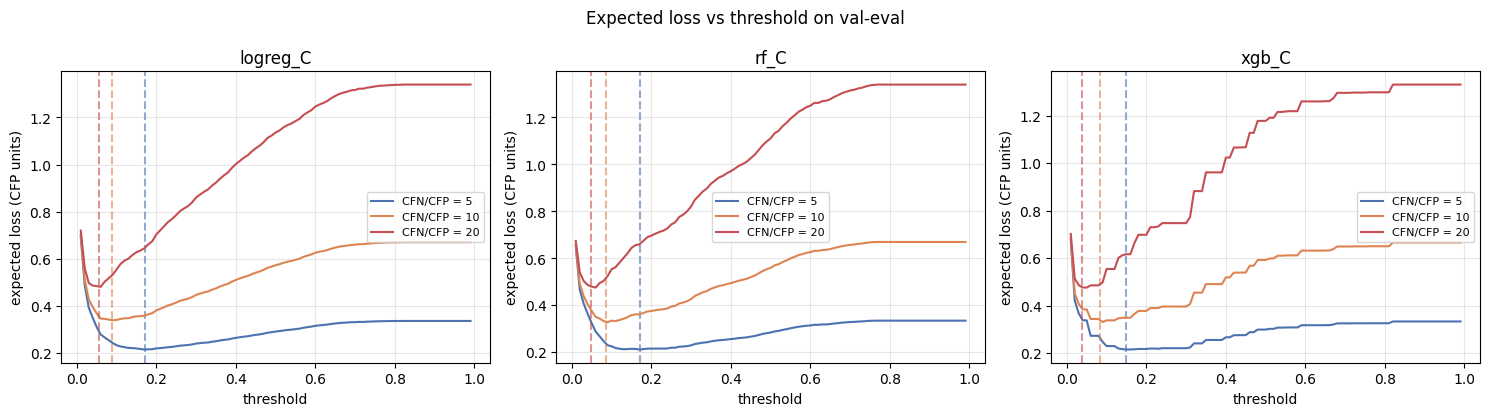

In [10]:
# Expected-loss curves per model with the cost-optimal thresholds marked. The curves are
# convex with a clear interior minimum that moves left as the cost ratio grows.
ratio_colors = {5: "#4C72B0", 10: "#DD8452", 20: "#C44E52"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, key in zip(axes, selected.values()):
    for ratio in COST_RATIOS:
        curve = el_curves[(key, ratio)]
        ax.plot(GRID, curve, color=ratio_colors[ratio], label=f"CFN/CFP = {ratio}")
        ax.axvline(cost_optimal[key][ratio], color=ratio_colors[ratio], ls="--", alpha=0.6)
    ax.set_title(key)
    ax.set_xlabel("threshold")
    ax.set_ylabel("expected loss (CFP units)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Expected loss vs threshold on val-eval")
plt.tight_layout()
plt.show()

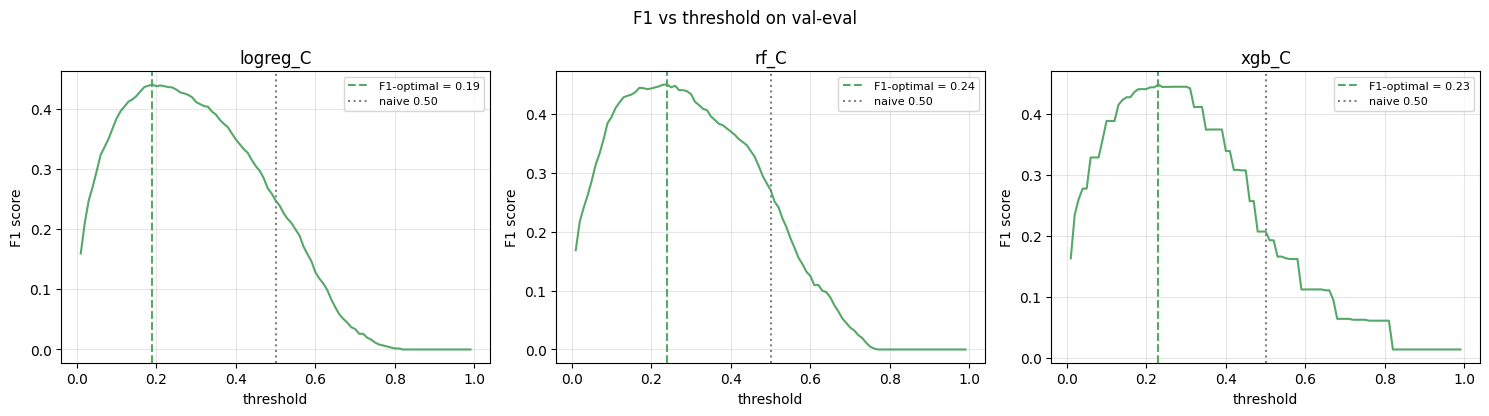

In [11]:
# F1 curves per model with the F1-optimal and the naive threshold marked. The naive 0.5
# sits far to the right of every optimum - with a 6.7% default rate, almost nobody gets
# a calibrated probability above 0.5, which is why the naive policy approves nearly all.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, key in zip(axes, selected.values()):
    ax.plot(GRID, f1_curves[key], color="#55A868")
    ax.axvline(f1_optimal[key], color="#55A868", ls="--",
               label=f"F1-optimal = {f1_optimal[key]:.2f}")
    ax.axvline(0.50, color="grey", ls=":", label="naive 0.50")
    ax.set_title(key)
    ax.set_xlabel("threshold")
    ax.set_ylabel("F1 score")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("F1 vs threshold on val-eval")
plt.tight_layout()
plt.show()

In [12]:
# Persist the chosen thresholds plus the decision-theory cross-check. Scoring 02 applies
# the thresholds to the test split without any re-optimisation, and Scoring 03 uses them
# for the subgroup comparison. The acceptance checks from the Issue 1 fix are asserted
# here: the searched optimum never has higher expected loss than t* (non-negative regret)
# and no selected threshold sits on the search boundary.
assert (theoretical["regret_t_star"] >= -1e-9).all(), \
    "negative regret remains: searched threshold beaten by t* on val-eval"
assert theoretical["t_grid"].between(0.001, 0.999, inclusive="neither").all(), \
    "a selected cost-optimal threshold sits on the search boundary"

theo_records = {key: {str(int(row.ratio)): {"t_star": float(row.t_star),
                                            "EL_grid": float(row.EL_grid),
                                            "EL_at_t_star": float(row.EL_at_t_star),
                                            "regret_t_star": float(row.regret_t_star)}
                      for row in grp.itertuples()}
                for key, grp in theoretical.groupby("model")}
thresholds = {key: {"naive": 0.50,
                    "f1": f1_optimal[key],
                    "cost_optimal": {str(r): cost_optimal[key][r] for r in COST_RATIOS},
                    "theoretical": theo_records[key]}
              for key in selected.values()}
(ARTIFACTS / "thresholds.json").write_text(json.dumps(thresholds, indent=2))
print("saved: thresholds.json (incl. theoretical t* cross-check; regret >= 0 asserted)")

saved: thresholds.json (incl. theoretical t* cross-check; regret >= 0 asserted)
